# Нелинейный упругий стержень

**Цели:**
- Базовая модель (малые деформации): решить краевую задачу методом стрельбы.
- Геометрическая нелинейность (конечные деформации): то же, но без малых приближений.
- Сравнение методов: стрельба (brent) и Ньютон.

Уравнения:
$$\theta''(s) + \frac{P}{EI}\sin\theta(s) = 0, \quad x'(s)=\cos\theta, y'(s)=\sin\theta$$
Условия: $\theta(0)=0$, $\theta'(0)=k_0$ ищем такое, чтобы $\theta'(L)=0$ (свободный конец)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

plt.rcParams['figure.figsize'] = (8,5)

# Параметры стержня
L = 1.0  # длина, м
E = 2.1e11  # модуль Юнга, Па
I = 1e-6  # момент инерции, м^4
EI = E*I

In [2]:
# Система ODE: z = [theta, k, x, y]
def elastica_rhs(s, z, P):
    theta, k, x, y = z
    return [k, -(P/EI)*np.sin(theta), np.cos(theta), np.sin(theta)]

def shoot_k0(k0, P):
    z0 = [0.0, k0, 0.0, 0.0]
    sol = solve_ivp(lambda s, z: elastica_rhs(s, z, P), [0,L], z0, rtol=1e-8, atol=1e-8, max_step=L/200)
    kL, thetaL, xL, yL = sol.y[1,-1], sol.y[0,-1], sol.y[2,-1], sol.y[3,-1]
    return kL, thetaL, xL, yL, sol

In [3]:
# Метод Брента с предварительным сканом
def find_k0_brent(P, k0_bounds=(-50,50), nscan=101):
    ks = np.linspace(k0_bounds[0], k0_bounds[1], nscan)
    vals = np.array([shoot_k0(k,P)[0] for k in ks])
    idx = np.where(np.sign(vals[:-1]) != np.sign(vals[1:]))[0]
    if len(idx)==0:
        return None, ks, vals
    i = idx[0]
    k_lo, k_hi = ks[i], ks[i+1]
    sol = root_scalar(lambda k: shoot_k0(k,P)[0], bracket=(k_lo,k_hi), method='brentq', xtol=1e-8)
    k0 = sol.root
    kL, thetaL, xL, yL, sol_ivp = shoot_k0(k0, P)
    return dict(k0=k0, kL=kL, thetaL=thetaL, xL=xL, yL=yL, sol=sol_ivp), ks, vals

In [4]:
# Метод Ньютона (одномерный)
def find_k0_newton(P, k0_init, tol=1e-8, maxiter=50, h=1e-6):
    k = float(k0_init)
    for _ in range(maxiter):
        f = shoot_k0(k,P)[0]
        df = (shoot_k0(k+h,P)[0] - f)/h
        if abs(df)<1e-14: break
        k_new = k - f/df
        if abs(k_new - k)<tol: k = k_new; break
        k = k_new
    kL, thetaL, xL, yL, sol_ivp = shoot_k0(k,P)
    return dict(k0=k, kL=kL, thetaL=thetaL, xL=xL, yL=yL, sol=sol_ivp)

Brent k0 = 0.0 y_tip = 0.0
Newton refined k0 = 0.0 y_tip = 0.0


Text(0.5, 1.0, 'Форма стержня')

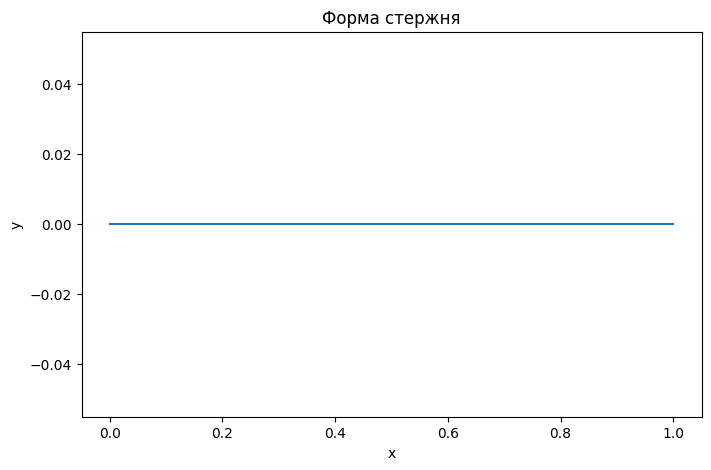

In [5]:
# Пример для одного P
P_test = 100.0
res_brent, ks_scan, vals_scan = find_k0_brent(P_test, k0_bounds=(-10,10), nscan=201)
if res_brent is None:
    i_best = np.nanargmin(np.abs(vals_scan))
    print('Brent не нашёл брукет. k_guess =', ks_scan[i_best])
    res_newt = find_k0_newton(P_test, ks_scan[i_best])
    print('Newton k0 =', res_newt['k0'], 'y_tip =', res_newt['yL'])
else:
    print('Brent k0 =', res_brent['k0'], 'y_tip =', res_brent['yL'])
    res_newt = find_k0_newton(P_test, res_brent['k0'])
    print('Newton refined k0 =', res_newt['k0'], 'y_tip =', res_newt['yL'])

# График стержня
sol = res_brent['sol'] if res_brent is not None else res_newt['sol']
plt.figure(); plt.plot(sol.y[2], sol.y[3]); plt.xlabel('x'); plt.ylabel('y'); plt.title('Форма стержня')

Общее время расчета = 23.80 s


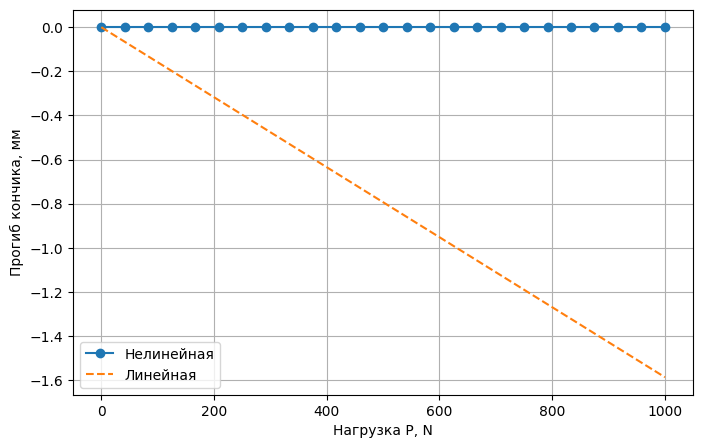

In [6]:
# Диаграмма нагрузка — прогиб
P_vals = np.linspace(0,1000,25)
y_nl = np.empty_like(P_vals)
k0_nl = np.empty_like(P_vals)

start = perf_counter()
for i,P in enumerate(P_vals):
    res, ks, vals = find_k0_brent(P, k0_bounds=(-50,50), nscan=201)
    if res is None:
        i_best = int(np.nanargmin(np.abs(vals)))
        res_n = find_k0_newton(P, ks[i_best])
        y_nl[i] = res_n['yL']
        k0_nl[i] = res_n['k0']
    else:
        y_nl[i] = res['yL']
        k0_nl[i] = res['k0']

t_total = perf_counter()-start
print('Общее время расчета = %.2f s' % t_total)

# Линейная теория
y_lin = -P_vals * L**3 / (3*EI)

plt.figure(); plt.plot(P_vals, y_nl*1e3, '-o', label='Нелинейная')
plt.plot(P_vals, y_lin*1e3, '--', label='Линейная')
plt.xlabel('Нагрузка P, N'); plt.ylabel('Прогиб кончика, мм'); plt.legend(); plt.grid(True)